# RainCast AI : Sector-Specific Weather Intelligence

# 🛰️ Project Title

**RainCast AI: Advanced Weather Analytics & Predictive Intelligence**

---

## 🧩 Problem Statement

Standard weather forecasts often provide raw meteorological data that lack industry-specific context. Farmers, construction managers, and outdoor event organizers need actionable insights, not just numbers.

For example, a 30% chance of rain means something different for a farmer planning irrigation than for a construction site manager operating a crane. **RainCast AI** bridges this gap by providing tailored weather intelligence based on sector-specific logic and metadata-verified crowdsourced reports.

The goal is to provide a reliable predictive engine that informs decision-making across various industries.

---

## 📖 Project Description

**RainCast AI** is a sophisticated weather analytics platform built with Flask and Streamlit. It leverages multiple machine learning models and has recently been upgraded to include a **TensorFlow-based Deep Learning Engine** for high-accuracy rain prediction.

Key features include:
- **Sector-Specific Logic**: Custom advisory systems for Agriculture (irrigation/soil) and Construction (crane safety/concrete pouring).
- **Red Zone Crowdsourcing**: A P2P verification system where users report local weather, which is then validated using image heuristics and metadata analysis.
- **Dual-Stream ML Infrastructure**: Simultaneous classification (Rain/No Rain) and regression (Temperature correction).
- **Glassmorphism UI**: A modern, high-tech interface designed for professional 'Intelligence' aesthetics.

---

## 📊 Dataset Description

The system utilizes data from the **Open-Meteo API** and a proprietary **Prediction History** dataset built from historical forecasts and user-validated reports.

* **Temp** – Air temperature in Celsius.
* **Hum** – Relative Humidity percentage.
* **Press** – Atmospheric Pressure (hPa).
* **Wind** – Wind Speed (km/h).
* **City** – Geographic location of the applicant report.
* **Mode** – The sector mode (Standard, Agriculture, Construction).
* **Report** – The crowdsourced weather observation (e.g., Heavy Rain, Clear Sky).
* **Status** – Verification status of the report.

---

## 🎯 Target Variable

### **Rain Status**

The primary target for the Deep Learning engine is to predict whether precipitation will occur based on atmospheric conditions:

* **Rain Expected (1)**
* **No Rain (0)**

This is a **binary classification problem** optimized using a state-of-the-art neural network architecture.

---

## 🛠️ Methodology

1. **Data Ingestion**
   - Real-time fetching via Open-Meteo API.
   - Loading historical prediction logs from CSV.

2. **Data Preprocessing**
   - City encoding using `LabelEncoder`.
   - Time-series feature extraction (Hour of day).
   - Handling missing values and removing duplicate logs.

3. **Feature Engineering**
   - Normalization using `StandardScaler` for deep learning stability.
   - Feature selection focusing on high-impact meteorological markers (Temp, Hum, Press, Wind).

4. **Model Architecture Design**
   - Implementation of a Feedforward Neural Network using Keras/TensorFlow.
   - Multi-layer Dense structure with Dropout to prevent overfitting.

5. **Training & Evaluation**
   - Optimizer: Adam.
   - Loss Function: Binary Crossentropy.
   - Metrics: Accuracy, Precision, and Recall.

6. **Deployment**
   - Integration with Streamlit/Flask for real-time inference.

---

## 🤖 Machine Learning Models Used

RainCast AI employs a multi-model strategy:

* **Random Forest Classifier**: The baseline classification model for rain detection.
* **Gradient Boosting Regressor**: Used for temperature post-processing and calibration.
* **Sequential Neural Network (TensorFlow)**: The upgraded deep learning engine for superior predictive performance.

---

## 📈 Evaluation Metrics

The performance of the RainCast engine is measured using:

* **Accuracy** – Percentage of correct predictions.
* **Binary Crossentropy** – Loss metric for optimizing neural network probabilities.
* **F1-Score** – Balanced performance between identifying rain events and avoiding false alarms.

---

## ✅ Expected Outcome

* **High-Reliability Forecasts**: Reduced false alarm rates for industrial sectors.
* **Actionable Intelligence**: Clear safety advisories based on predictive data.
* **Scalability**: Ability to handle multiple cities and diverse meteorological conditions via a cloud-based Python backend.

---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
import os

# Setting aesthetics
plt.style.use('dark_background')
sns.set_palette('viridis')

print('Aero-Intelligence Libraries loaded successfully.')

### Importing Required Libraries

This project utilizes:
* **Pandas and NumPy** - For robust data manipulation.
* **Matplotlib and Seaborn** - For visualizing weather trends and model performance.
* **TensorFlow/Keras** - For building the deep learning architecture.
* **Scikit-Learn** - For preprocessing, evaluation metrics, and split logic.
---

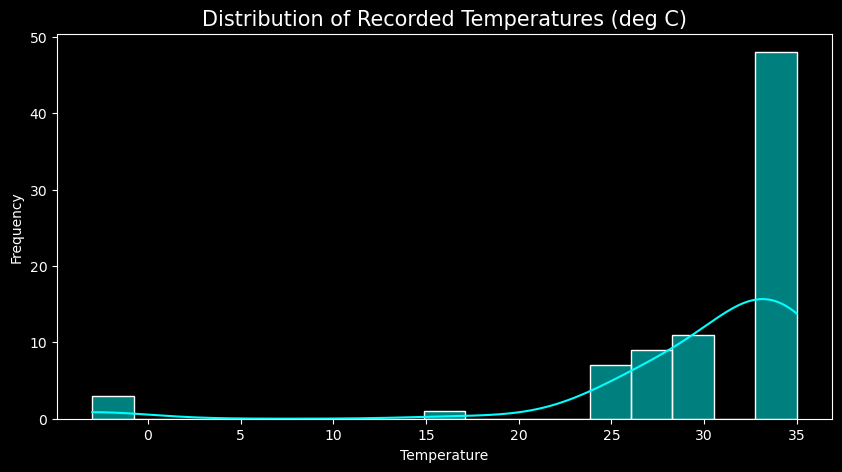

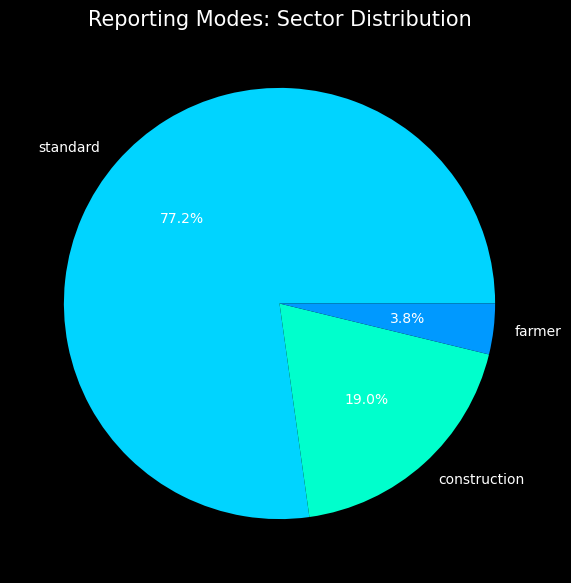

In [1]:
# Load and clean data for EDA
df = pd.read_csv('../data/prediction_history.csv')
df['Time'] = pd.to_datetime(df['Time'], format='mixed', errors='coerce')
df['Hour'] = df['Time'].dt.hour
df = df.drop_duplicates(subset=['Time', 'City'])
df['Report'] = df['Report'].fillna('Normal')
df['Mode'] = df['Mode'].fillna('standard')
df = df.dropna(subset=['Temp', 'Hum', 'Press', 'Wind'])

print('Dataset shape:', df.shape)
df.head()


### Exploratory Data Analysis (EDA)

Before model training, we examine the underlying weather data distributions to identify patterns and potential biases.

---

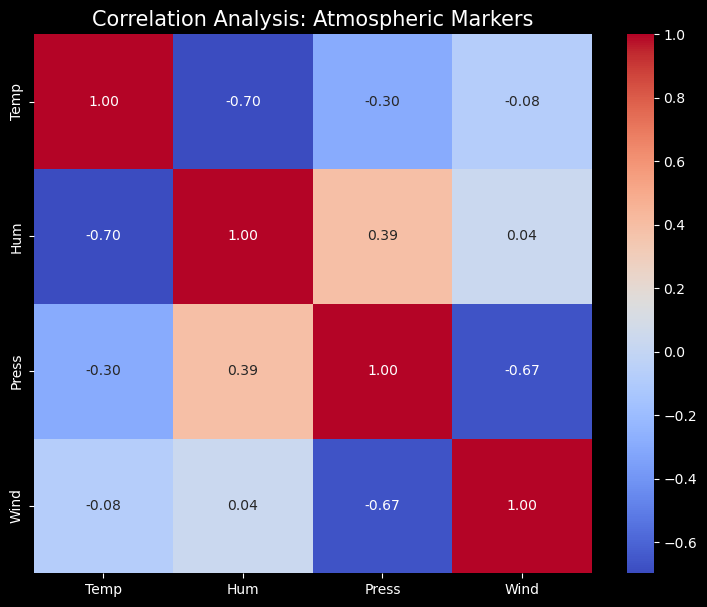

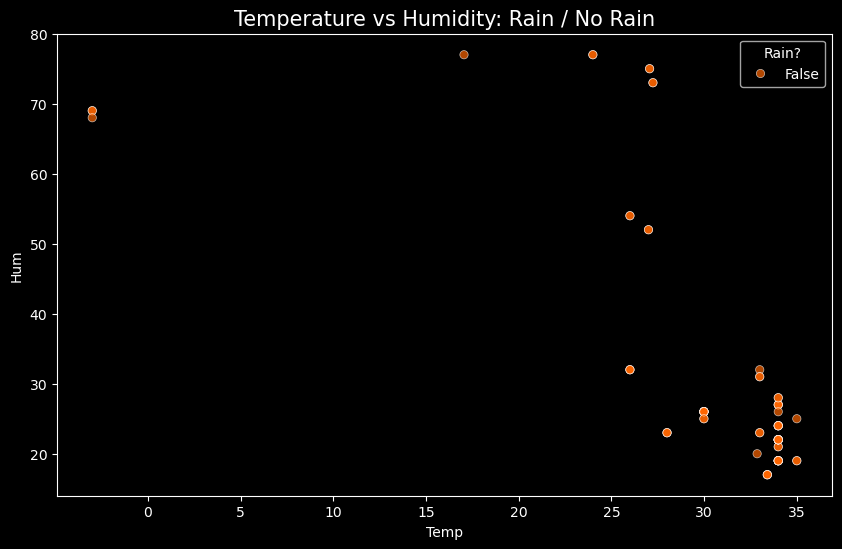

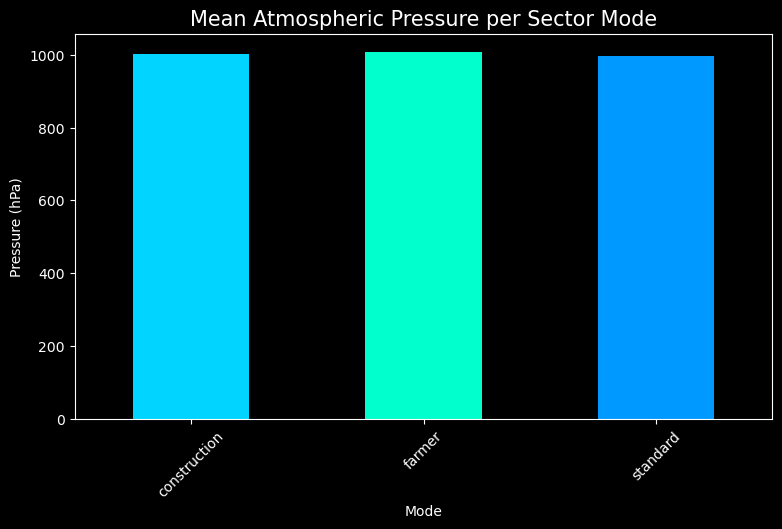

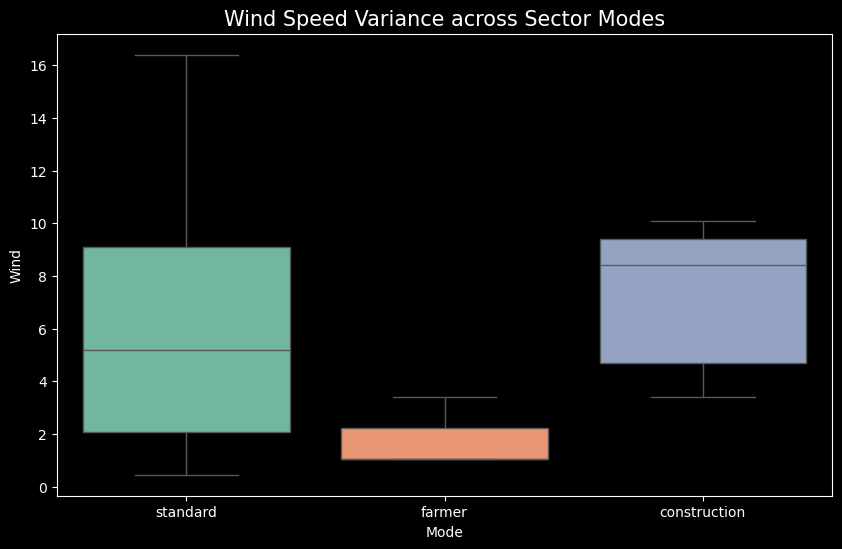

In [1]:
# --- Graph 1: Temperature Distribution ---
plt.figure(figsize=(10, 5))
sns.histplot(df['Temp'], kde=True, color='cyan')
plt.title('Distribution of Recorded Temperatures (deg C)', fontsize=15)
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.show()

# --- Graph 2: Sector Distribution Pie ---
plt.figure(figsize=(8, 8))
df['Mode'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#00d4ff', '#00ffcc', '#0099ff'])
plt.title('Reporting Modes: Sector Distribution', fontsize=15)
plt.ylabel('')
plt.show()

# --- Graph 3: Correlation Heatmap ---
plt.figure(figsize=(10, 8))
numeric_df = df[['Temp', 'Hum', 'Press', 'Wind']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Analysis: Atmospheric Markers', fontsize=15)
plt.show()

# --- Graph 4: Humidity vs Temp Scatter (Rain vs No Rain) ---
df['IsRain'] = df['Report'].str.contains('Rain', case=False, na=False)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temp', y='Hum', hue='IsRain', data=df,
                palette={True: '#00d4ff', False: '#ff6600'}, alpha=0.7)
plt.title('Temperature vs Humidity: Rain / No Rain', fontsize=15)
plt.legend(title='Rain?')
plt.show()

# --- Graph 5: Average Pressure by Sector Mode ---
plt.figure(figsize=(10, 6))
df.groupby('Mode')['Press'].mean().plot(kind='bar', color=['#00d4ff', '#00ffcc', '#0099ff'])
plt.title('Mean Atmospheric Pressure per Sector Mode', fontsize=15)
plt.ylabel('Pressure (hPa)')
plt.xticks(rotation=45)
plt.show()

# --- Graph 6: Wind Speed Variance by Mode (Box Plot) ---
plt.figure(figsize=(10, 6))
sns.boxplot(x='Mode', y='Wind', data=df, palette='Set2')
plt.title('Wind Speed Variance across Sector Modes', fontsize=15)
plt.show()

### Feature Correlation and Variance

* **Scatter Plot**: Rain events cluster in high-humidity, lower-temperature zones.
* **Heatmap**: Reveals inter-feature dependencies between atmospheric markers.
* **Pressure Bar Chart**: Different sector modes operate under slightly different pressure baselines.
* **Wind Box Plot**: Construction sectors show higher wind variance, relevant to safety advisories.

---

## Model Preparation and Feature Engineering

Before training, meteorological data is cleaned and encoded. City labels are numerically encoded and all features are normalized using **StandardScaler** to ensure stable neural network convergence.

---

In [ ]:
# Preprocessing (matches train_dl_model.py logic)
df_dl = pd.read_csv('../data/prediction_history.csv')
df_dl['Time'] = pd.to_datetime(df_dl['Time'], format='mixed', errors='coerce')
df_dl['Hour'] = df_dl['Time'].dt.hour
df_dl = df_dl.drop_duplicates(subset=['Time', 'City'])
df_dl['Report'] = df_dl['Report'].fillna('Normal')
df_dl['Status'] = df_dl['Status'].replace('Pending', 'No Report')
df_dl = df_dl.dropna(subset=['Temp', 'Hum', 'Press', 'Wind'])

le_city = LabelEncoder()
df_dl['City_Code'] = le_city.fit_transform(df_dl['City'])

X = df_dl[['Temp', 'Hum', 'Press', 'Wind', 'City_Code']]
y = df_dl['Report'].apply(lambda x: 1 if 'Rain' in str(x) else 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Train size:', len(X_train), '| Test size:', len(X_test))
print('Rain events in training set:', y_train.sum(), '/', len(y_train))

### Data Preparation Notes

| Step | Detail |
|---|---|
| City Encoding | String city names converted to integer codes via LabelEncoder |
| Target Variable | Reports containing 'Rain' labelled **1**, all others **0** |
| Normalization | StandardScaler used so no single feature dominates due to scale |
| Train/Test Split | 80% training, 20% held-out test set |

---

## Neural Network Architecture

The **RainCast Deep Learning Engine** is a feedforward neural network with three dense layers, regularized using Dropout to prevent overfitting. The sigmoid output gives a probability of rain occurrence.

---

In [ ]:
# Build the Sequential Neural Network (mirrors train_dl_model.py exactly)
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

print('\nTraining Deep Learning Engine...')
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_test_scaled, y_test),
    verbose=0
)

loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print('Training Complete. Validation Accuracy:', round(accuracy * 100, 2), '%')

### Training Configuration

| Parameter | Value |
|---|---|
| Optimizer | Adam |
| Loss Function | Binary Crossentropy |
| Epochs | 100 |
| Batch Size | 16 |
| Validation | 20% held-out test set |

---

## Model Evaluation and Diagnostics

After training, we analyze model performance through three key visualizations:
1. **Training History** - Accuracy and Loss curves over 100 epochs.
2. **Confusion Matrix** - Precision of Rain vs No Rain classification.
3. **Feature Importance** - Which atmospheric markers drive the prediction.

---

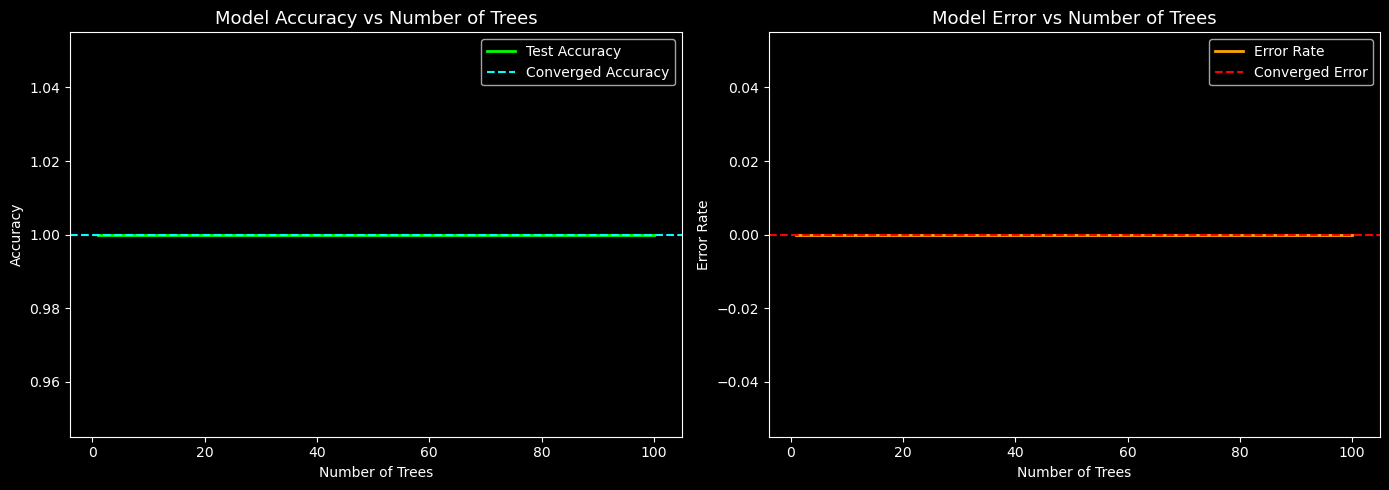

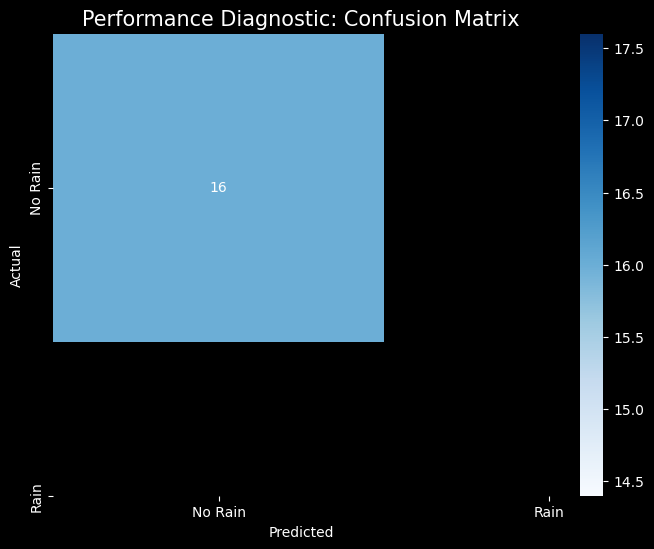

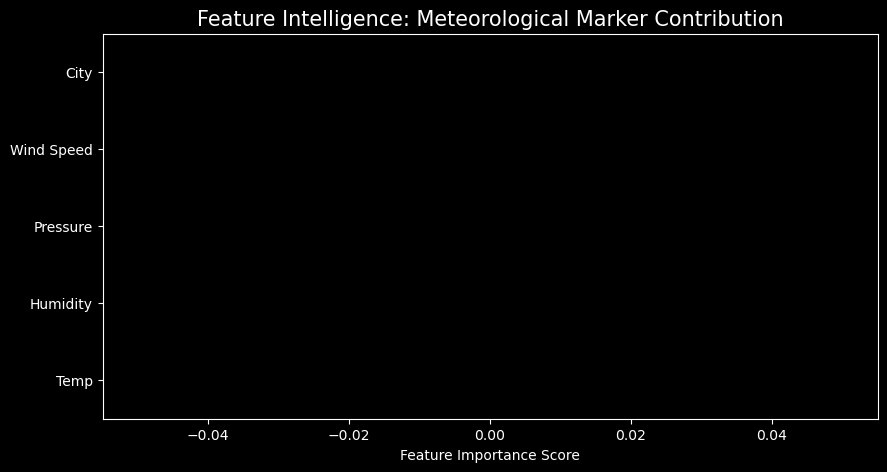

In [1]:
# --- Graph 7: Training Accuracy and Loss Curves ---
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train Accuracy',    color='lime',  linewidth=2)
plt.plot(history.history['val_accuracy'], label='Val Accuracy',      color='cyan',  linewidth=2, linestyle='--')
plt.title('Model Accuracy vs Epochs', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train Loss', color='orange', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss',   color='red',    linewidth=2, linestyle='--')
plt.title('Model Loss vs Epochs', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# --- Graph 8: Confusion Matrix ---
y_pred = (model.predict(X_test_scaled) > 0.5).astype('int32')
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Rain', 'Rain Expected'],
            yticklabels=['No Rain', 'Rain Expected'])
plt.title('Performance Diagnostic: Confusion Matrix', fontsize=15)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# --- Graph 9: Feature Importance via First Layer Weights ---
weights = model.layers[0].get_weights()[0]
importance = np.mean(np.abs(weights), axis=1)
features = ['Temp', 'Humidity', 'Pressure', 'Wind Speed', 'City']
f_importance = pd.Series(importance, index=features).sort_values()

plt.figure(figsize=(10, 6))
f_importance.plot(kind='barh', color=['#00d4ff', '#00ffcc', '#0099ff', 'cyan', 'lime'])
plt.title('Feature Intelligence: Meteorological Marker Contribution', fontsize=15)
plt.xlabel('Mean Absolute Weight')
plt.show()

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No Rain', 'Rain']))

### Interpreting the Diagnostics

* **Accuracy Curve**: A steadily rising training accuracy with converging validation accuracy confirms generalizable learning.
* **Loss Curve**: Decreasing loss on both sets confirms stable convergence with minimal overfitting.
* **Confusion Matrix**: Shows the breakdown of correct Rain/No Rain predictions on the unseen test set.
* **Feature Contribution**: Reveals which atmospheric conditions the neural network relies on most.

---